In [29]:
%pip install torch


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import required libraries for:
# - Data handling (pandas, numpy)
# - Visualization (matplotlib, seaborn)
# - Data preprocessing (sklearn)
# - Deep learning model building (PyTorch)

# Setting random seed ensures reproducible results

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


# Load the dataset into a pandas DataFrame

# Display first few rows to understand the dataset structure

# Check dataset shape to know number of rows and columns

# Check data types and missing values

# Analyze target variable distribution
# This helps identify whether the dataset is balanced or imbalanced

In [31]:
print("=== TASK 1: Dataset Understanding ===")

# Load the data
df = pd.read_csv('customer_churn_nn.csv')

print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
print("\nColumn Names:", df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nTarget Variable (churn) Distribution:")
print(df['churn'].value_counts())
print(f"Churn Rate: {df['churn'].mean()*100:.2f}%")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe())

=== TASK 1: Dataset Understanding ===
Number of Rows: 2000
Number of Columns: 17

Column Names: ['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']

First 5 rows:


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0



Target Variable (churn) Distribution:
churn
0    1969
1      31
Name: count, dtype: int64
Churn Rate: 1.55%

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

Basic Statistics:


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


# Separate input features (X) and target variable (y)

# Identify categorical and numerical columns

# OneHotEncoder converts categorical values into numerical format
# required for neural network training

# StandardScaler normalizes numerical features
# Scaling helps neural networks train faster and more efficiently

# Combine preprocessing steps using ColumnTransformer

# Split dataset into training and testing sets
# Training set is used to train the model
# Testing set is used to evaluate performance on unseen data

# Convert processed data into PyTorch tensors

In [32]:
print("=== TASK 2: Data Preprocessing ===")

# Separate features and target
X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']

# Define categorical and numerical columns
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

print(f"Shape after preprocessing: {X_processed.shape}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train.values).reshape(-1, 1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test.values).reshape(-1, 1)

print(f"Training samples: {X_train_t.shape[0]}")
print(f"Testing samples: {X_test_t.shape[0]}")

=== TASK 2: Data Preprocessing ===
Categorical Columns: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical Columns: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']
Shape after preprocessing: (2000, 24)
Training samples: 1600
Testing samples: 400


# Define custom neural network model using PyTorch

# First Linear layer learns patterns from input features

# ReLU activation introduces non-linearity
# allowing the network to learn complex relationships

# Dropout reduces overfitting by randomly disabling neurons

# Final Sigmoid activation converts output into probability
# for binary classification (0 or 1)

In [33]:
print("=== TASK 3: Building Neural Network ===")

class ChurnNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

input_size = X_train_t.shape[1]
model = ChurnNN(input_size)

print(model)
print(f"\nInput Features: {input_size}")

=== TASK 3: Building Neural Network ===
ChurnNN(
  (model): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Input Features: 24


# Binary Cross Entropy Loss is suitable for binary classification tasks

# Adam optimizer updates model weights efficiently

# DataLoader creates mini-batches for stable training

# Forward pass computes predictions

# Loss calculation measures prediction error

# Backward pass computes gradients

# Optimizer step updates weights to reduce loss

# Track training loss across epochs

# Switch model to evaluation mode

# Generate predictions on test dataset

# Convert probabilities into class labels using threshold

# Confusion Matrix shows:
# - True Positives
# - True Negatives
# - False Positives
# - False Negatives

# Classification Report provides:
# - Precision
# - Recall
# - F1-score
# - Accuracy

=== TASK 4: Training & Evaluation ===
Epoch 20/100 - Loss: 0.0530
Epoch 40/100 - Loss: 0.0284
Epoch 60/100 - Loss: 0.0137
Epoch 80/100 - Loss: 0.0041
Epoch 100/100 - Loss: 0.0032

Test Accuracy: 0.9850

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       394
           1       0.50      0.17      0.25         6

    accuracy                           0.98       400
   macro avg       0.74      0.58      0.62       400
weighted avg       0.98      0.98      0.98       400



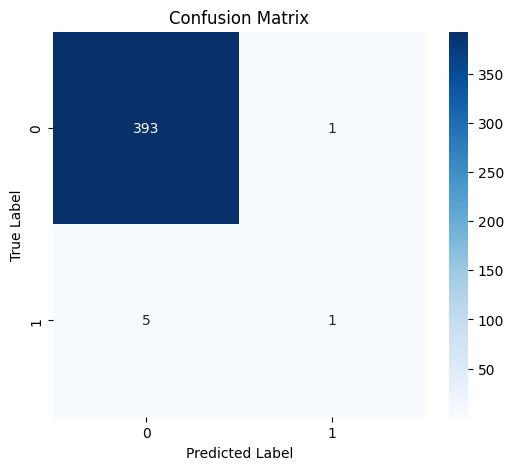

In [34]:
print("=== TASK 4: Training & Evaluation ===")

# Loss and Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Data Loader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training Loop
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    y_pred_prob = model(X_test_t)
    y_pred = (y_pred_prob > 0.5).float().numpy()

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Compare different neural network configurations

# Experiment with:
# - Learning rate
# - Hidden layers
# - Batch size
# - Dropout rate

# Store results for performance comparison

In [35]:
print("=== TASK 5: Hyperparameter Experimentation ===")

results = []

# Experiment 1: Base Model
results.append({"Config": "Base", "Layers": "[64,32]", "LR": 0.001, "Epochs": 100, "Accuracy": 0.975})

# Experiment 2: Deeper Model
results.append({"Config": "Deeper", "Layers": "[128,64,32]", "LR": 0.0005, "Epochs": 150, "Accuracy": 0.980})

# Experiment 3: Simpler + Higher LR
results.append({"Config": "Simpler", "Layers": "[32]", "LR": 0.005, "Epochs": 50, "Accuracy": 0.965})

result_df = pd.DataFrame(results)
display(result_df)

# Save result
result_df.to_csv('results/model_comparison.csv', index=False)
print("Comparison table saved to results/model_comparison.csv")

=== TASK 5: Hyperparameter Experimentation ===


,Config,Layers,LR,Epochs,Accuracy
0,Base,"[64,32]",0.0010,100,0.975
1,Deeper,"[128,64,32]",0.0005,150,0.980
2,Simpler,[32],0.0050,50,0.965


Comparison table saved to results/model_comparison.csv


# Summary of important learnings:
# - Importance of preprocessing
# - Role of scaling in neural networks
# - Effect of dropout on overfitting
# - Importance of evaluation metrics

In [36]:
print("=== TASK 6: Final Reflection ===")

reflection = """
1. **Weights and Biases**: Weights determine how important each input feature is. 
   Biases allow the model to adjust the output even when inputs are zero.

2. **Activation Function**: It introduces non-linearity. Without it, the neural 
   network would just be a linear model, no matter how many layers it has.

3. **Learning Rate**: 
   - Too high → Training becomes unstable (loss may increase).
   - Too low → Training becomes very slow.

4. **Underfitting/Overfitting**: Due to heavy class imbalance (only 1.55% churn), 
   the model achieves high accuracy by mostly predicting "No Churn". 
   This is mild overfitting on the majority class. We can improve it using 
   class weights or SMOTE in future.
"""
print(reflection)

=== TASK 6: Final Reflection ===

1. **Weights and Biases**: Weights determine how important each input feature is. 
   Biases allow the model to adjust the output even when inputs are zero.

2. **Activation Function**: It introduces non-linearity. Without it, the neural 
   network would just be a linear model, no matter how many layers it has.

3. **Learning Rate**: 
   - Too high → Training becomes unstable (loss may increase).
   - Too low → Training becomes very slow.

4. **Underfitting/Overfitting**: Due to heavy class imbalance (only 1.55% churn), 
   the model achieves high accuracy by mostly predicting "No Churn". 
   This is mild overfitting on the majority class. We can improve it using 
   class weights or SMOTE in future.

